In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# PHẦN 1: Khám phá & Trực quan hóa Dữ liệu (20%)

In [9]:
df = pd.read_csv("archive (1)/data.csv")
df.drop(columns=["Unnamed: 32", "id"], inplace=True, errors="ignore")

print(f"Kích thước tập dữ liệu: {df.shape[0]} mẫu, {df.shape[1]} cột")
print(f" features: {df.shape[1] - 1}")

print("\nKiểm tra missing values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Không có missing values")
print(f"\nTổng missing: {df.isnull().sum().sum()}")
df.head()

Kích thước tập dữ liệu: 569 mẫu, 31 cột
 features: 30

Kiểm tra missing values:
Không có missing values

Tổng missing: 0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
print("Phân bố cột diagnosis:")
print(df["diagnosis"].value_counts())
print(f'\nTỷ lệ B: {df["diagnosis"].value_counts(normalize=True)["B"]:.2%}')
print(f'Tỷ lệ M: {df["diagnosis"].value_counts(normalize=True)["M"]:.2%}')
print("\nThống kê mô tả:")
df.describe().round(3)

Phân bố cột diagnosis:
diagnosis
B    357
M    212
Name: count, dtype: int64

Tỷ lệ B: 62.74%
Tỷ lệ M: 37.26%

Thống kê mô tả:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,13.010,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208


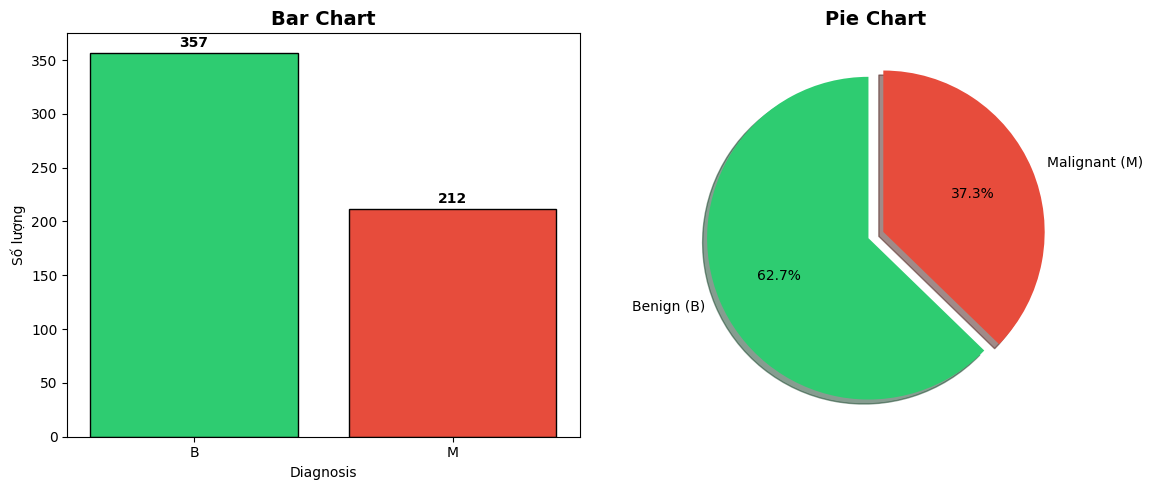

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#2ecc71", "#e74c3c"]
counts = df["diagnosis"].value_counts()

axes[0].bar(counts.index, counts.values, color=colors, edgecolor="black")
axes[0].set_title("Bar Chart", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Số lượng")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=["Benign (B)", "Malignant (M)"],
           colors=colors, autopct="%1.1f%%", startangle=90,
           explode=(0.05, 0.05), shadow=True)
axes[1].set_title("Pie Chart", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

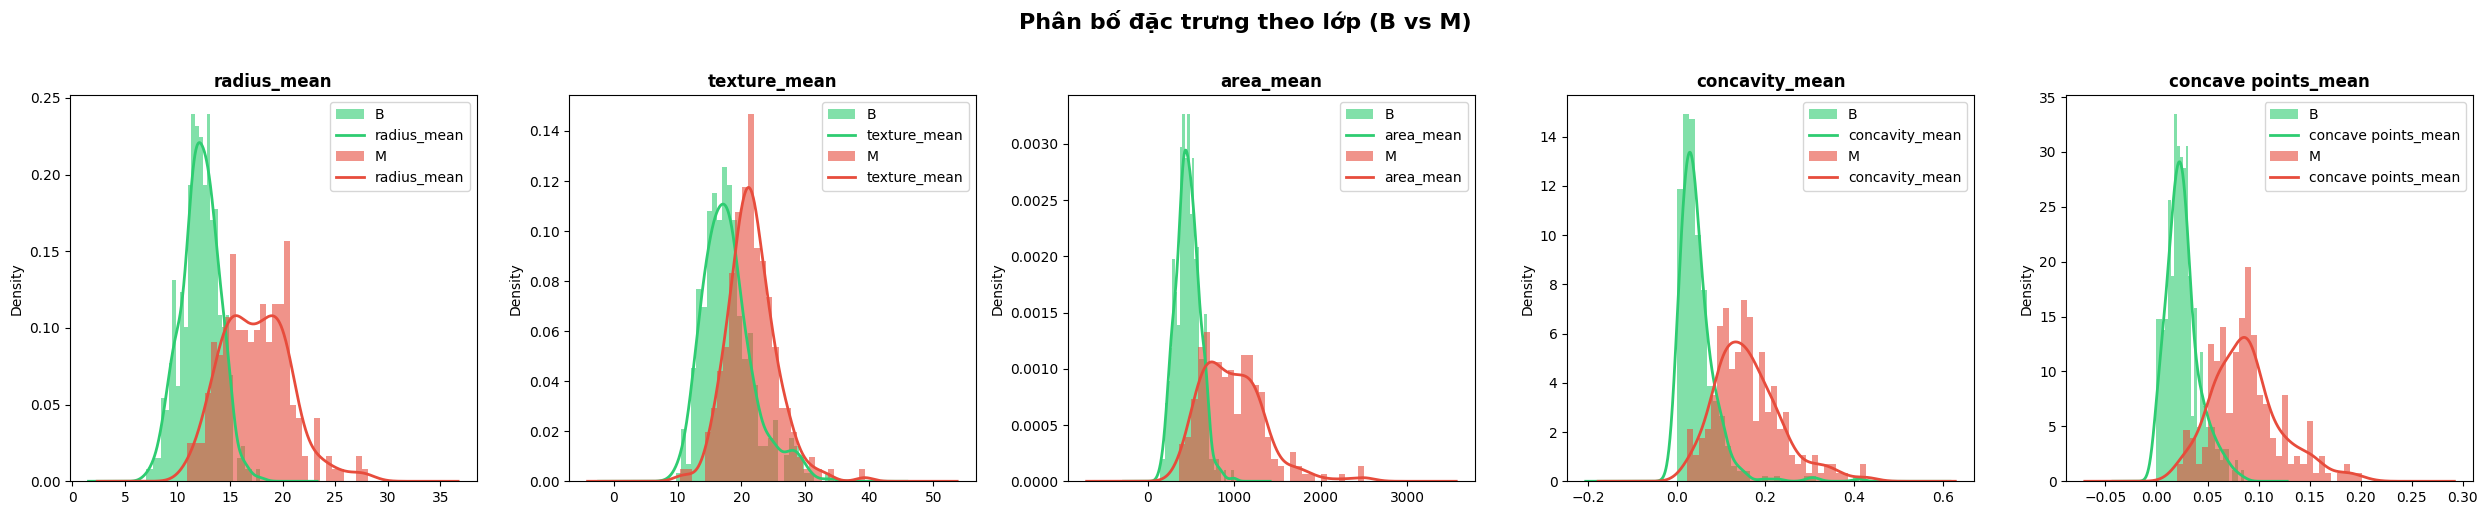

 Nhận xét: area_mean, concavity_mean, concave points_mean phân tách 2 lớp tốt nhất.


In [14]:
# Chọn 5 đặc trưng 
features_to_plot = ["radius_mean", "texture_mean", "area_mean",
                    "concavity_mean", "concave points_mean"]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, feat in enumerate(features_to_plot):
    for label, color in zip(["B", "M"], ["#2ecc71", "#e74c3c"]):
        subset = df[df["diagnosis"] == label][feat]
        axes[i].hist(subset, bins=30, alpha=0.6, label=label, color=color, density=True)
        subset.plot.kde(ax=axes[i], color=color, linewidth=2)
    axes[i].set_title(feat, fontsize=12, fontweight="bold")
    axes[i].legend()

plt.suptitle("Phân bố đặc trưng theo lớp (B vs M)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(" Nhận xét: area_mean, concavity_mean, concave points_mean phân tách 2 lớp tốt nhất.")

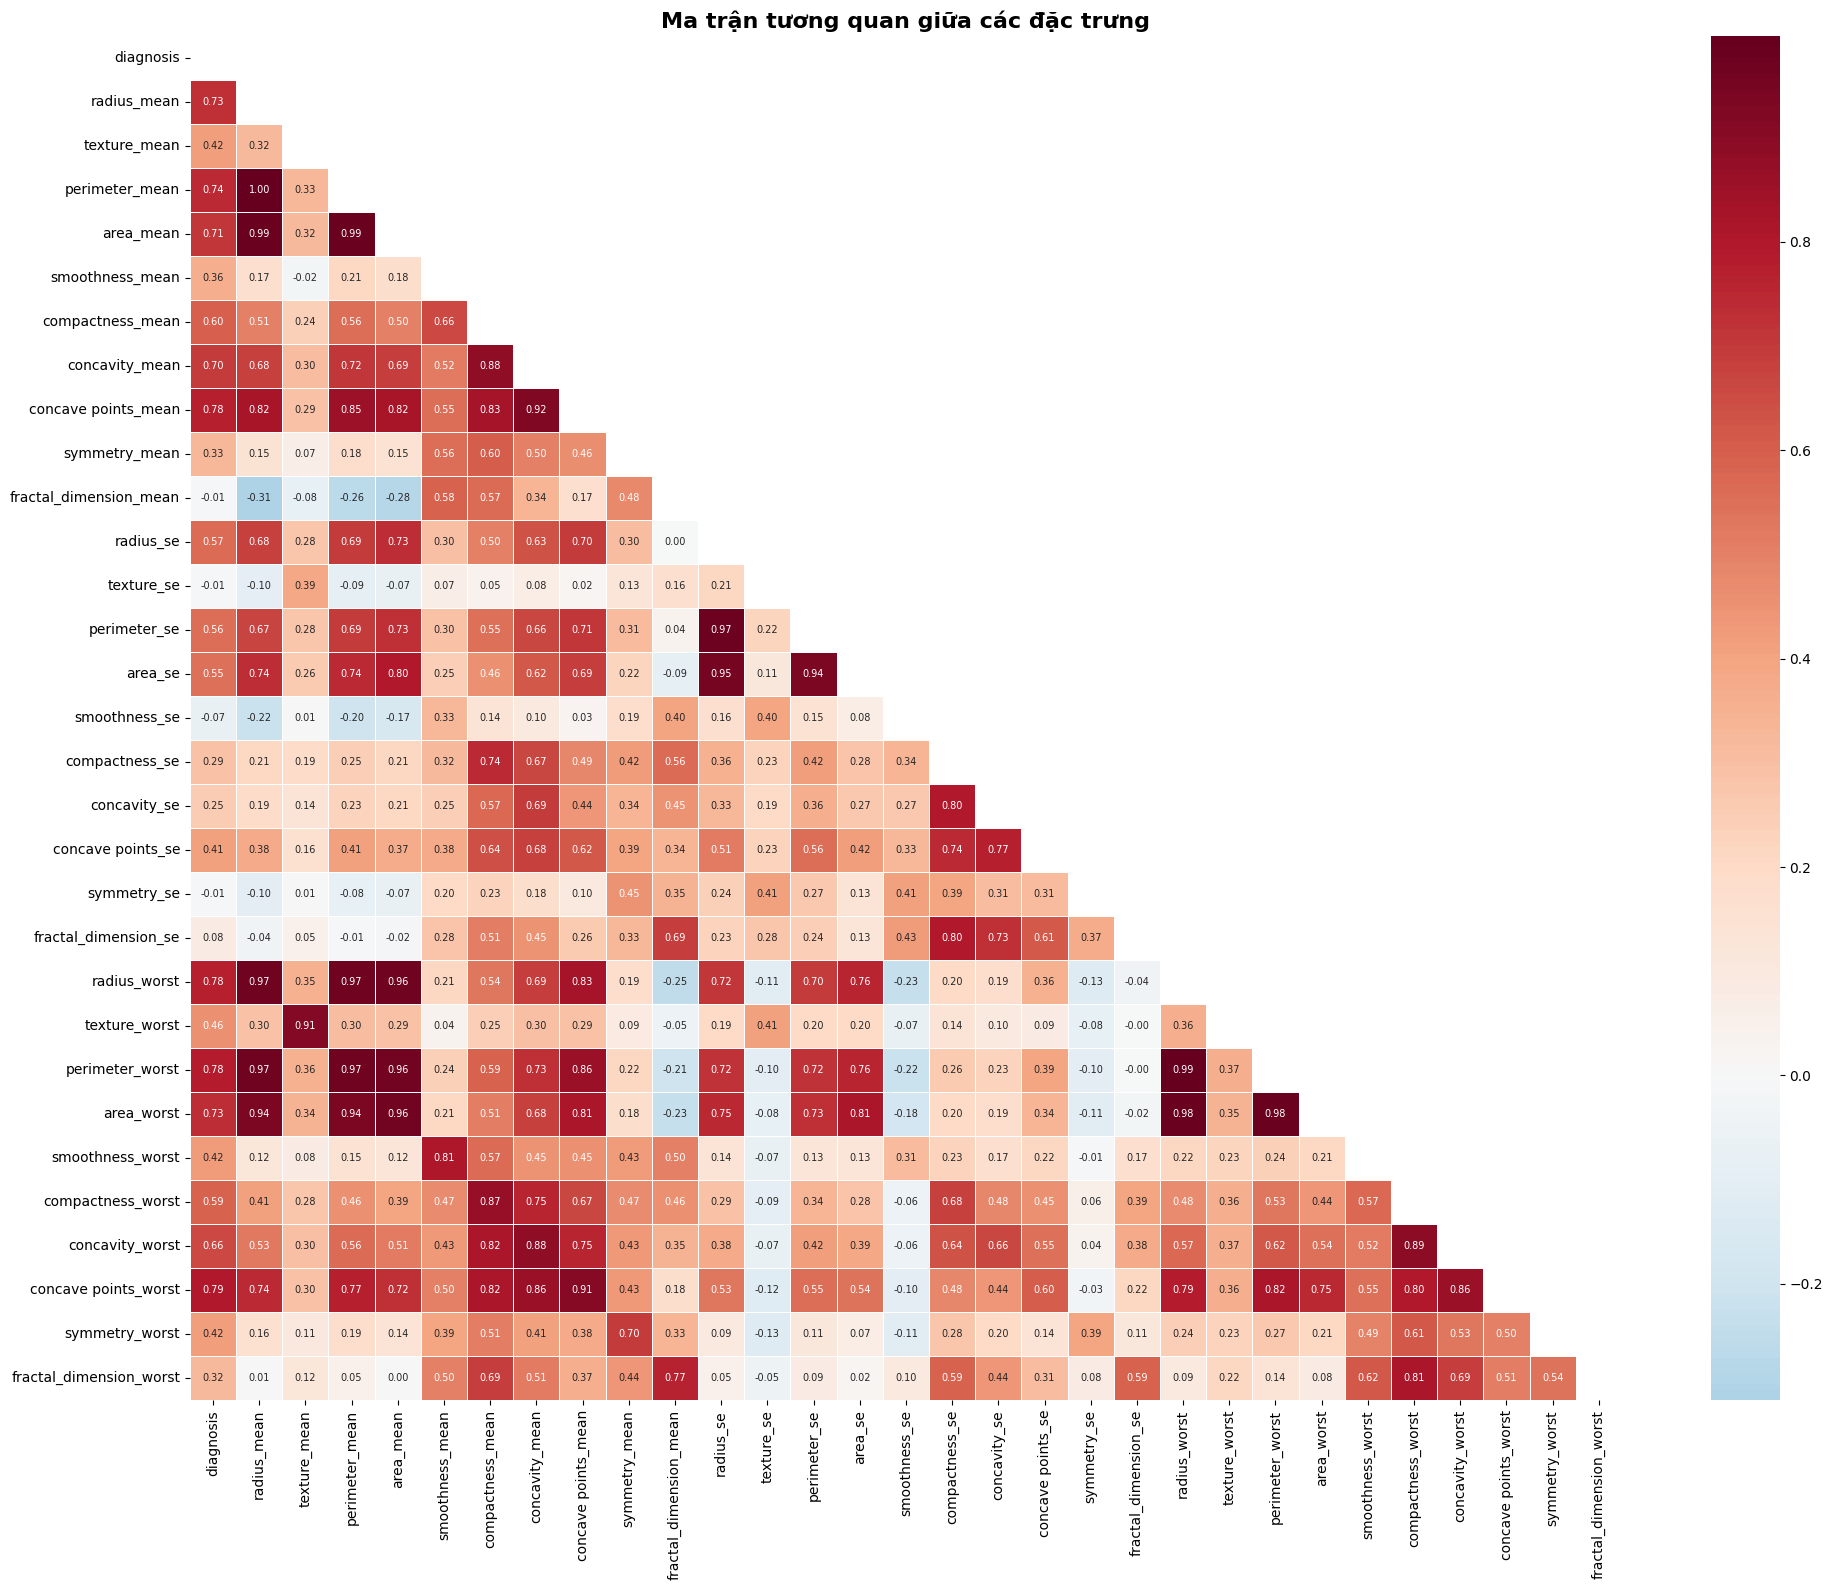


Top 10 đặc trưng tương quan mạnh nhất với diagnosis:
concave points_worst    0.7936
perimeter_worst         0.7829
concave points_mean     0.7766
radius_worst            0.7765
perimeter_mean          0.7426
area_worst              0.7338
radius_mean             0.7300
area_mean               0.7090
concavity_mean          0.6964
concavity_worst         0.6596
Name: diagnosis, dtype: float64

Cặp đặc trưng có multicollinearity cao (|corr| > 0.9):
  radius_mean <-> perimeter_mean: 0.998
  radius_mean <-> area_mean: 0.987
  radius_mean <-> radius_worst: 0.97
  radius_mean <-> perimeter_worst: 0.965
  radius_mean <-> area_worst: 0.941
  texture_mean <-> texture_worst: 0.912
  perimeter_mean <-> area_mean: 0.987
  perimeter_mean <-> radius_worst: 0.969
  perimeter_mean <-> perimeter_worst: 0.97
  perimeter_mean <-> area_worst: 0.942
  area_mean <-> radius_worst: 0.963
  area_mean <-> perimeter_worst: 0.959
  area_mean <-> area_worst: 0.959
  concavity_mean <-> concave points_mean: 0.921
 

In [15]:
plt.figure(figsize=(20, 16))

# Encode diagnosis tạm để tính correlation
df_corr = df.copy()
df_corr["diagnosis"] = df_corr["diagnosis"].map({"M": 1, "B": 0})

corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5,
            annot_kws={"size": 7})
plt.title("Ma trận tương quan giữa các đặc trưng", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Top features tương quan với diagnosis
print("\nTop 10 đặc trưng tương quan mạnh nhất với diagnosis:")
target_corr = corr_matrix["diagnosis"].drop("diagnosis").abs().sort_values(ascending=False)
print(target_corr.head(10).round(4))

print("\nCặp đặc trưng có multicollinearity cao (|corr| > 0.9):")
high_corr = []
cols = corr_matrix.columns.drop("diagnosis")
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if abs(corr_matrix.loc[cols[i], cols[j]]) > 0.9:
            high_corr.append((cols[i], cols[j], round(corr_matrix.loc[cols[i], cols[j]], 3)))
for a, b, c in high_corr:
    print(f"  {a} <-> {b}: {c}")

# PHẦN 2: Tiền xử lý Dữ liệu (20%)

In [16]:
# Label Encoding: M -> 1 (Ác tính), B -> 0 (Lành tính)
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  # B=0, M=1

print("Mapping: B (Benign) -> 0, M (Malignant) -> 1")
print(f"Phân bố sau encoding:\n{df['diagnosis'].value_counts()}")

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

Mapping: B (Benign) -> 0, M (Malignant) -> 1
Phân bố sau encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64

X shape: (569, 30), y shape: (569,)


In [17]:
#  Train (70%) / Validation (15%) / Test (15%)
# Train (70%) vs Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Validation (15%) vs Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train set: {X_train.shape[0]} mẫu ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val set:   {X_val.shape[0]} mẫu ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} mẫu ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nPhân bố lớp trong Train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Phân bố lớp trong Val:   {dict(zip(*np.unique(y_val, return_counts=True)))}")
print(f"Phân bố lớp trong Test:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

Train set: 398 mẫu (69.9%)
Val set:   85 mẫu (14.9%)
Test set:  86 mẫu (15.1%)

Phân bố lớp trong Train: {np.int64(0): np.int64(250), np.int64(1): np.int64(148)}
Phân bố lớp trong Val:   {np.int64(0): np.int64(53), np.int64(1): np.int64(32)}
Phân bố lớp trong Test:  {np.int64(0): np.int64(54), np.int64(1): np.int64(32)}


### Tại sao mạng nơ-ron nhạy cảm với scale của dữ liệu?

**Lý do cần chuẩn hóa dữ liệu cho Neural Network:**

1. **Gradient Descent hội tụ chậm**: Khi các đặc trưng có scale khác nhau lớn (ví dụ: `area_mean` ~ 100-2500 vs `smoothness_mean` ~ 0.05-0.16), gradient của các trọng số sẽ chênh lệch rất lớn. Điều này khiến quá trình tối ưu dao động mạnh (zigzag) và cần rất nhiều epoch để hội tụ.

2. **Hàm kích hoạt bị bão hòa**: Với sigmoid/tanh, nếu đầu vào có giá trị rất lớn, neuron sẽ rơi vào vùng bão hòa → gradient gần bằng 0 (vanishing gradient) → mạng không học được.

3. **Trọng số khởi tạo**: Các phương pháp khởi tạo trọng số (Xavier, He) giả định dữ liệu đầu vào có phân phối chuẩn hóa. Nếu dữ liệu chưa scale, việc khởi tạo sẽ không tối ưu.

**Tại sao chỉ được fit scaler trên tập Train?**

- Nếu fit scaler trên toàn bộ dữ liệu (bao gồm cả Val/Test), thông tin thống kê (mean, std) của tập Test sẽ "rò rỉ" vào quá trình tiền xử lý → **Data Leakage**.
- Trong thực tế, khi mô hình được triển khai, ta không có dữ liệu test/tương lai. Do đó, scaler chỉ được fit trên dữ liệu huấn luyện, rồi `transform` cho Val/Test để mô phỏng đúng điều kiện thực tế.

In [18]:
# Feature Scaling - StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_val_scaled = scaler.transform(X_val)        
X_test_scaled = scaler.transform(X_test)       

print("Trước khi scale (Train):")
print(f"  Mean: {X_train.values.mean():.4f}, Std: {X_train.values.std():.4f}")
print(f"  Min:  {X_train.values.min():.4f}, Max: {X_train.values.max():.4f}")

print("\nSau khi scale (Train):")
print(f"  Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"  Min:  {X_train_scaled.min():.4f}, Max: {X_train_scaled.max():.4f}")

Trước khi scale (Train):
  Mean: 62.0049, Std: 228.4860
  Min:  0.0000, Max: 3432.0000

Sau khi scale (Train):
  Mean: 0.0000, Std: 1.0000
  Min:  -2.7820, Max: 11.1545


# PHẦN 3: Xây dựng và Huấn luyện Mô hình với TensorFlow (30%)

In [19]:
# Kiến trúc mạng MLP 
# 4 Hidden layers với Dropout + L2 Regularization để chống overfitting
n_features = X_train_scaled.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    
    # Hidden layer 1
    layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden layer 2
    layers.Dense(64, activation="relu",
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden layer 3
    layers.Dense(32, activation="relu",
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    # Hidden layer 4
    layers.Dense(16, activation="relu",
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    # Output layer: 1 neuron, sigmoid -> xác suất [0, 1]
    # Sigmoid được chọn vì bài toán binary classification:
    #   output > 0.5 -> Malignant (1)
    #   output <= 0.5 -> Benign (0)
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,617 (61.00 KB)

 Trainable params: 15,233 (59.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [21]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",  # Hàm mất mát cho phân loại nhị phân
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)
print(f"Anti-overfitting: Dropout + L2 Regularization + Early Stopping + BatchNorm")

Anti-overfitting: Dropout + L2 Regularization + Early Stopping + BatchNorm


In [22]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\nTraining hoàn tất sau {len(history.history['loss'])} epochs")

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6884 - loss: 0.7692 - val_accuracy: 0.8000 - val_loss: 0.8407
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8141 - loss: 0.6268 - val_accuracy: 0.9294 - val_loss: 0.6798
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8618 - loss: 0.5509 - val_accuracy: 0.9647 - val_loss: 0.5486
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9045 - loss: 0.4635 - val_accuracy: 0.9765 - val_loss: 0.4658
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9397 - loss: 0.4023 - val_accuracy: 0.9647 - val_loss: 0.4008
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9422 - loss: 0.3653 - val_accuracy: 0.9529 - val_loss: 0.3560
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9397 - loss: 0.3453 - val_accuracy: 0.9647 - val_loss: 0.3289
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9623 - loss: 0.3226 - val_accuracy: 0.9882 - 

# PHẦN 4: Đánh giá & Trực quan hóa Kết quả Mô hình (20%)

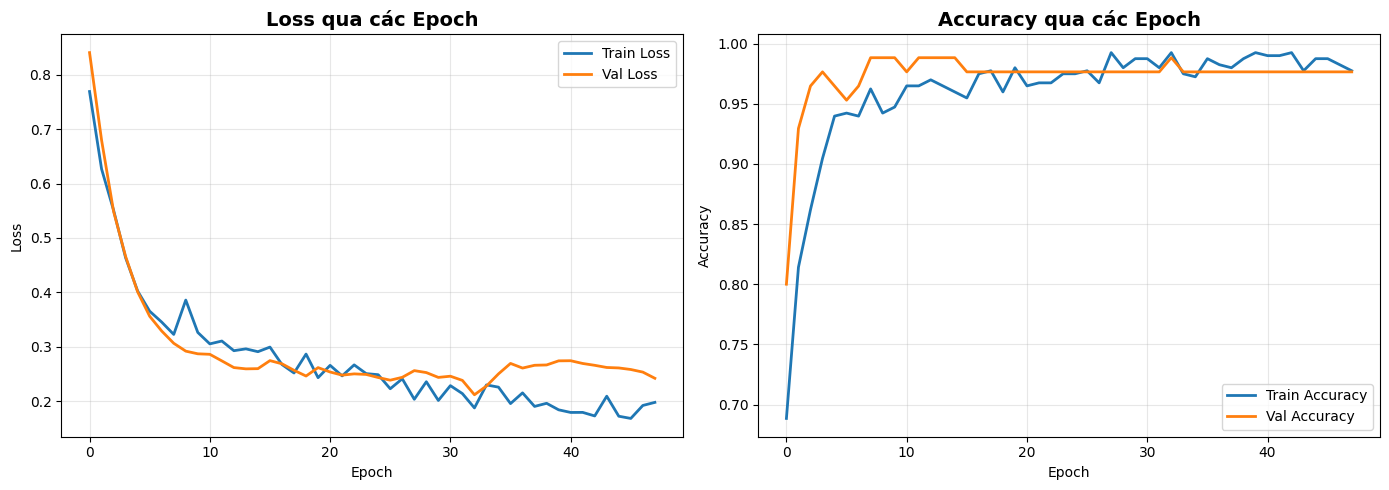

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history["loss"], label="Train Loss", linewidth=2)
axes[0].plot(history.history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_title("Loss qua các Epoch", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy", linewidth=2)
axes[1].set_title("Accuracy qua các Epoch", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Test Loss: 0.1793
Test Accuracy: 0.9884


### Giải thích các khái niệm trong ngữ cảnh Y tế (Chẩn đoán ung thư vú):

| Khái niệm | Ý nghĩa | Ngữ cảnh Y tế |
|---|---|---|
| **True Positive (TP)** | Dự đoán Malignant -> Thực tế Malignant | Phát hiện đúng bệnh nhân ung thư. Được điều trị kịp thời  |
| **True Negative (TN)** | Dự đoán Benign -> Thực tế Benign | Xác nhận đúng người khỏe mạnh. Tránh điều trị không cần thiết  |
| **False Positive (FP)** | Dự đoán Malignant -> Thực tế Benign | Chẩn đoán nhầm người khỏe thành ung thư. Gây lo lắng, xét nghiệm thêm  |
| **False Negative (FN)** | Dự đoán Benign -> Thực tế Malignant | **BỎ SÓT ung thư**  Bệnh nhân không được điều trị. Nguy hiểm tính mạng  |

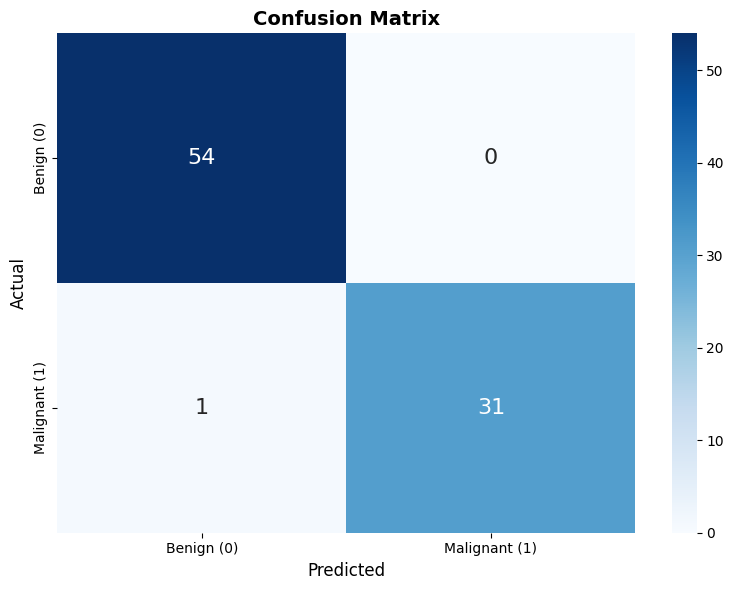

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign (0)", "Malignant (1)"],
            yticklabels=["Benign (0)", "Malignant (1)"],
            annot_kws={"size": 16})
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()

In [31]:
print("Classification Report:")
print(classification_report(y_test, y_pred,
                           target_names=["Benign (0)", "Malignant (1)"]))

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"  Trong các ca dự đoán Malignant, {precision*100:.1f}% thực sự là Malignant")
print(f"\nRecall: {recall:.4f}")
print(f"  Trong các ca thực sự Malignant, mô hình phát hiện được {recall*100:.1f}%")
print(f"\nF1-Score: {f1:.4f}")

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.98      1.00      0.99        54
Malignant (1)       1.00      0.97      0.98        32

     accuracy                           0.99        86
    macro avg       0.99      0.98      0.99        86
 weighted avg       0.99      0.99      0.99        86

Precision: 1.0000
  Trong các ca dự đoán Malignant, 100.0% thực sự là Malignant

Recall: 0.9688
  Trong các ca thực sự Malignant, mô hình phát hiện được 96.9%

F1-Score: 0.9841


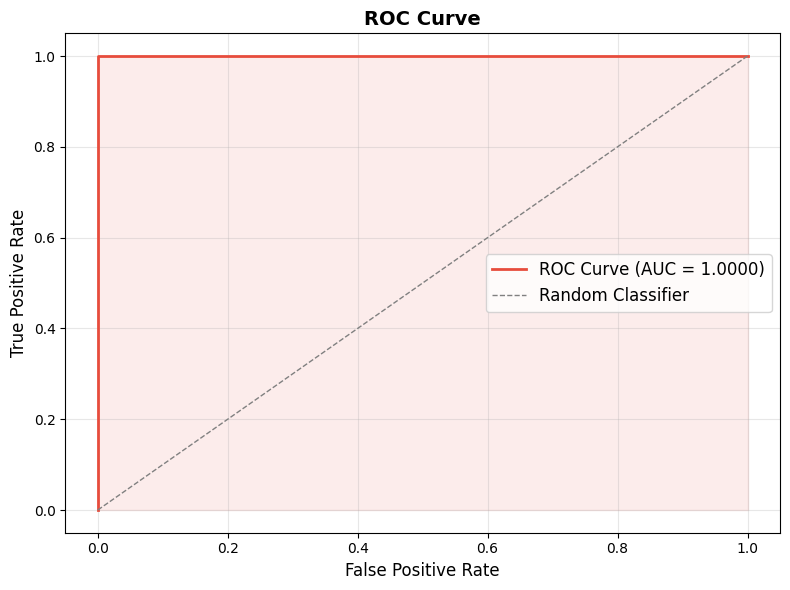

AUC = 1.0000


In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#e74c3c", linewidth=2,
         label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1,
         label="Random Classifier")
plt.fill_between(fpr, tpr, alpha=0.1, color="#e74c3c")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve", fontsize=14, fontweight="bold")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC = {roc_auc:.4f}")

# PHẦN 5: Câu hỏi Tư duy / Thảo luận (10%)

### Câu 1: False Negative vs False Positive - Trường hợp nào nghiêm trọng hơn?


Trong chẩn đoán ung thư, **False Negative nghiêm trọng hơn** False Positive.

- **False Negative (FN)**: Bệnh nhân bị ung thư nhưng mô hình dự đoán là khỏe mạnh. Hậu quả: bệnh nhân không được điều trị kịp thời, ung thư có thể tiến triển nặng hơn, đe dọa tính mạng.
- **False Positive (FP)**: Người khỏe mạnh bị chẩn đoán nhầm là ung thư. Hậu quả: gây lo lắng và cần xét nghiệm thêm, nhưng có thể khắc phục được.

Do đó, ta nên **tối ưu Recall** vì Recall = TP / (TP + FN). Recall cao đồng nghĩa với việc giảm thiểu FN, tức là ít bỏ sót bệnh nhân ung thư hơn. Trong y tế, việc phát hiện sớm bệnh luôn quan trọng hơn việc tránh báo động nhầm.

### Câu 2: Nếu bỏ qua Feature Scaling, loss sẽ biến thiên như thế nào?

Nếu không chuẩn hóa dữ liệu, loss sẽ có các biểu hiện sau:

1. **Loss khởi đầu rất cao** do các đặc trưng có scale chênh lệch lớn.
2. **Loss dao động mạnh** vì gradient descent sẽ di chuyển không ổn định.
3. **Hội tụ chậm hoặc không hội tụ** - cần nhiều epoch hơn hoặc không đạt được kết quả tốt.
4. **Accuracy thấp hơn** so với mô hình được train trên dữ liệu đã scale.

Minh chứng bằng code ở cell tiếp theo.

In [35]:
# Minh chứng: Train mô hình không có Feature Scaling
model_no_scale = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model_no_scale.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train trên dữ liệu chưa scale (X_train gốc)
history_no_scale = model_no_scale.fit(
    X_train.values, y_train,
    validation_data=(X_val.values, y_val),
    epochs=100,
    batch_size=32,
    verbose=0
)

print("Training xong model không scale")

Training xong model không scale


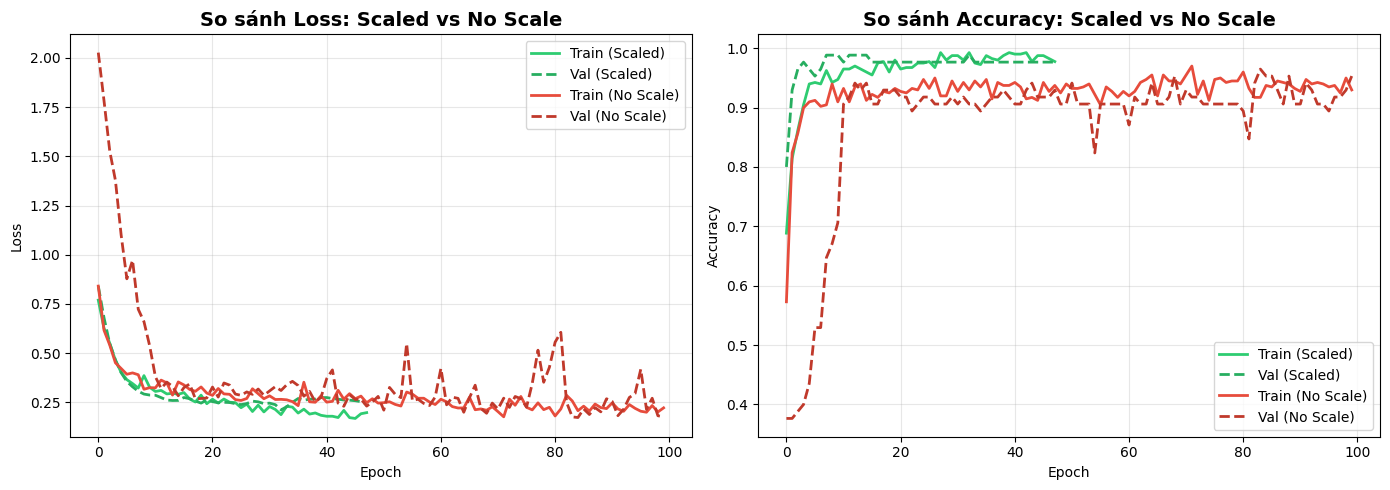


Test Accuracy (Scaled):    0.9884
Test Accuracy (No Scale): 0.9535

 -> Mô hình có Scale cho kết quả tốt hơn và loss ổn định hơn!


In [36]:
# So sánh Loss giữa 2 mô hình: có Scale vs không Scale
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(history.history["loss"], label="Train (Scaled)", linewidth=2, color="#2ecc71")
axes[0].plot(history.history["val_loss"], label="Val (Scaled)", linewidth=2, color="#27ae60", linestyle="--")
axes[0].plot(history_no_scale.history["loss"], label="Train (No Scale)", linewidth=2, color="#e74c3c")
axes[0].plot(history_no_scale.history["val_loss"], label="Val (No Scale)", linewidth=2, color="#c0392b", linestyle="--")
axes[0].set_title("So sánh Loss: Scaled vs No Scale", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(history.history["accuracy"], label="Train (Scaled)", linewidth=2, color="#2ecc71")
axes[1].plot(history.history["val_accuracy"], label="Val (Scaled)", linewidth=2, color="#27ae60", linestyle="--")
axes[1].plot(history_no_scale.history["accuracy"], label="Train (No Scale)", linewidth=2, color="#e74c3c")
axes[1].plot(history_no_scale.history["val_accuracy"], label="Val (No Scale)", linewidth=2, color="#c0392b", linestyle="--")
axes[1].set_title("So sánh Accuracy: Scaled vs No Scale", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

_, acc_scaled = model.evaluate(X_test_scaled, y_test, verbose=0)
_, acc_no_scale = model_no_scale.evaluate(X_test.values, y_test, verbose=0)
print(f"\nTest Accuracy (Scaled):    {acc_scaled:.4f}")
print(f"Test Accuracy (No Scale): {acc_no_scale:.4f}")
print(f"\n -> Mô hình có Scale cho kết quả tốt hơn và loss ổn định hơn!")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


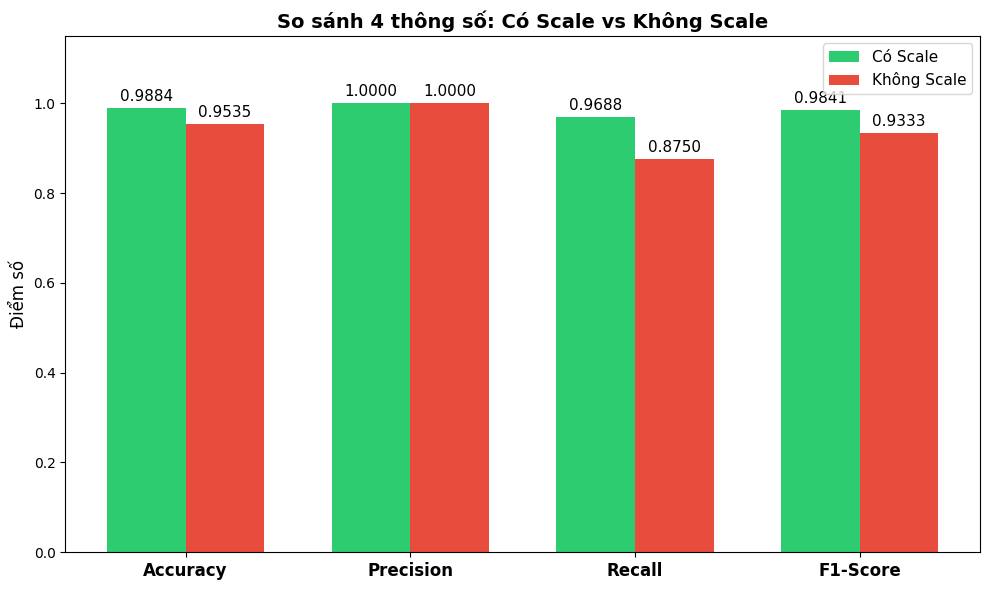


Bảng so sánh chi tiết:
   Metric  Có Scale  Không Scale
 Accuracy  0.988372     0.953488
Precision  1.000000     1.000000
   Recall  0.968750     0.875000
 F1-Score  0.984127     0.933333


In [37]:
y_pred_prob_no_scale = model_no_scale.predict(X_test.values).flatten()
y_pred_no_scale = (y_pred_prob_no_scale >= 0.5).astype(int)

metrics_scaled = [
    test_acc,  
    precision, 
    recall, 
    f1         
]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_no_scale = [
    accuracy_score(y_test, y_pred_no_scale),
    precision_score(y_test, y_pred_no_scale, zero_division=0),
    recall_score(y_test, y_pred_no_scale, zero_division=0),
    f1_score(y_test, y_pred_no_scale, zero_division=0)
]


labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, metrics_scaled, width, label='Có Scale', color='#2ecc71')
rects2 = ax.bar(x + width/2, metrics_no_scale, width, label='Không Scale', color='#e74c3c')

ax.set_ylabel('Điểm số', fontsize=12)
ax.set_title('So sánh 4 thông số: Có Scale vs Không Scale', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.15)  
ax.legend(loc='upper right', fontsize=11)


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


import pandas as pd
df_compare = pd.DataFrame({
    'Metric': labels,
    'Có Scale': metrics_scaled,
    'Không Scale': metrics_no_scale
})
print("\nBảng so sánh chi tiết:")
print(df_compare.to_string(index=False))